In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 10,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]

In [2]:
#No metallicity dependance
t_array = np.linspace(0.001,14,int(1e3))
m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
gal1 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp)
Z_Fe_1 = gal1.compute_z_Fe()
Z_O_1 = gal1.compute_z_O()
eq_Fe_1 = gal1.analytic_eq_Fe(SFR_function="constant")

Text(0, 0.5, '[Fe/O]')

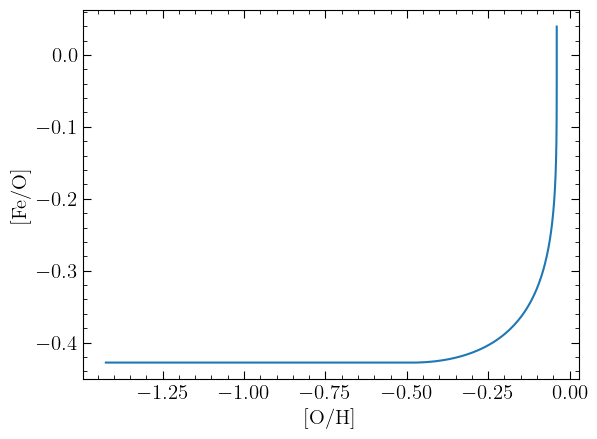

In [3]:
plt.plot(gal1.O_H[1:], gal1.Fe_O[1:])
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

In [4]:
def get_X_O_met_dep(O_H, O_Fe, alpha_cc, alpha_Ia, R_Ia):
    A_Ia_A_cc = 10**(0.3 - O_Fe) - 1
    X_O = alpha_cc * O_H + np.log10((1 + R_Ia * (A_Ia_A_cc) * 10**((alpha_Ia-alpha_cc)*O_H))/(1 + R_Ia))
    return X_O

Text(0, 0.5, '[Mn/O]')

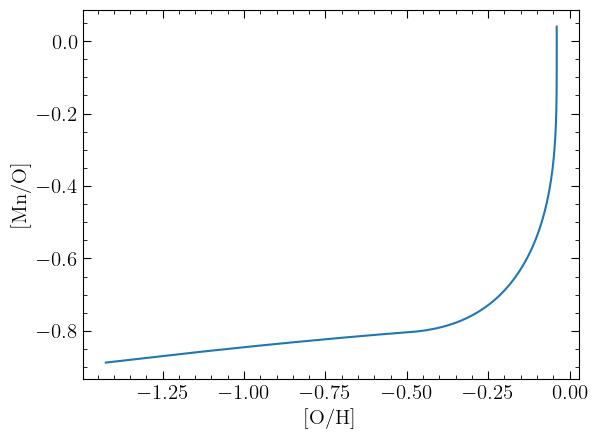

In [5]:
Mn_O_example = get_X_O_met_dep(gal1.O_H[:], O_Fe=gal1.O_Fe[:], alpha_cc=0.17, alpha_Ia=0.3, R_Ia=1.97)

plt.plot(gal1.O_H[1:], Mn_O_example[1:])
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')

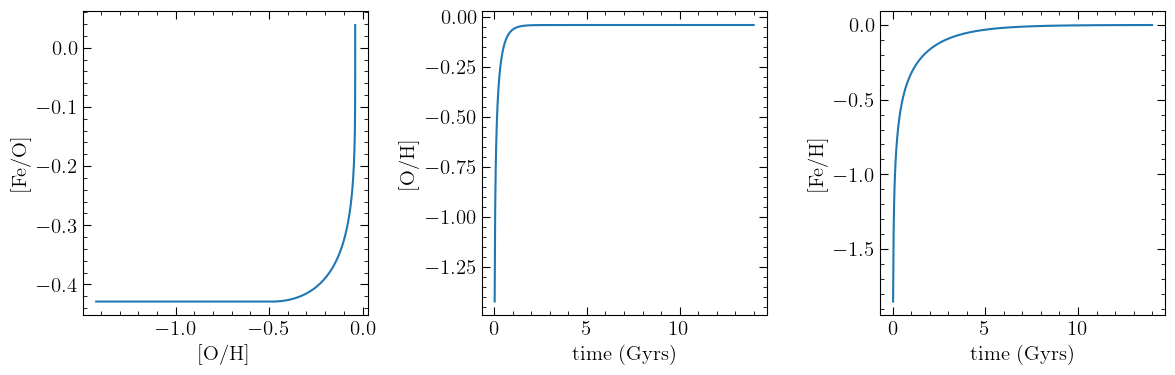

In [6]:
Fe_O_example = get_X_O_met_dep(gal1.O_H, O_Fe=gal1.O_Fe, alpha_cc=0, alpha_Ia=0, R_Ia=1)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(gal1.O_H[1:], Fe_O_example[1:])
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.subplot(1,3,2)
plt.plot(gal1.t[1:], gal1.O_H[1:])
plt.xlabel('time (Gyrs)')
plt.ylabel('[O/H]')

plt.subplot(1,3,3)
plt.plot(gal1.t[1:], gal1.Fe_H[1:])
plt.xlabel('time (Gyrs)')
plt.ylabel('[Fe/H]')
plt.tight_layout()

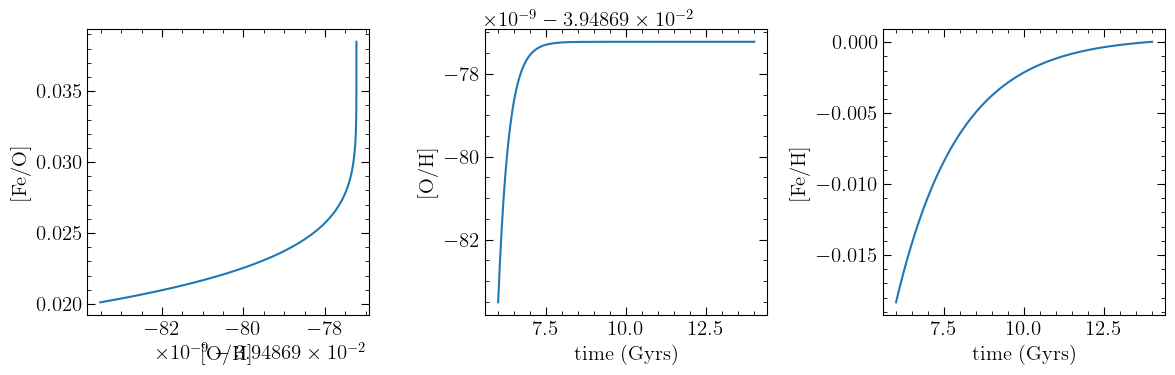

In [7]:
Fe_O_example = get_X_O_met_dep(gal1.O_H[:], O_Fe=gal1.O_Fe[:], alpha_cc=0, alpha_Ia=0, R_Ia=1)
mask = gal1.t > 6.0

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(gal1.O_H[mask], Fe_O_example[mask])
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.subplot(1,3,2)
plt.plot(gal1.t[mask], gal1.O_H[mask])
plt.xlabel('time (Gyrs)')
plt.ylabel('[O/H]')

plt.subplot(1,3,3)
plt.plot(gal1.t[mask], gal1.Fe_H[mask])
plt.xlabel('time (Gyrs)')
plt.ylabel('[Fe/H]')
plt.tight_layout()

Text(0, 0.5, '[Fe/O] from my code')

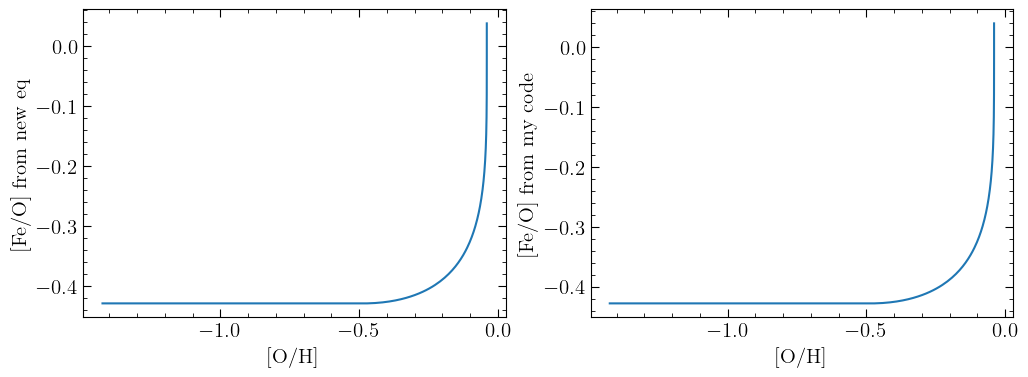

In [8]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(gal1.O_H[1:], Fe_O_example[1:])
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O] from new eq')

plt.subplot(1,2,2)
plt.plot(gal1.O_H[1:], gal1.Fe_O[1:])
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O] from my code')

Text(0, 0.5, '[X/O]')

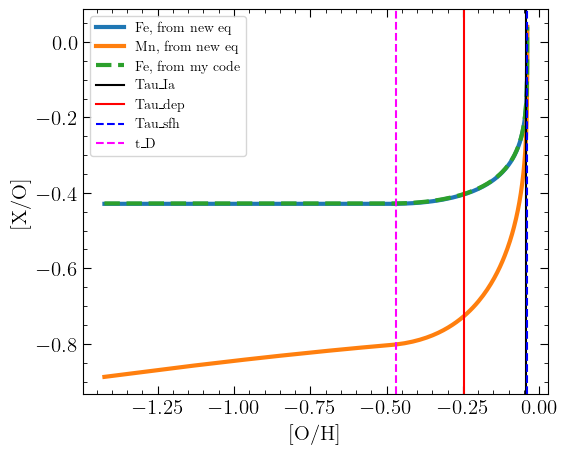

In [9]:
plt.figure(figsize=(6,5))

plt.plot(gal1.O_H[1:], Fe_O_example[1:], label = 'Fe, from new eq', lw = 3)
plt.plot(gal1.O_H[1:], Mn_O_example[1:], label = 'Mn, from new eq', lw = 3)
plt.plot(gal1.O_H[1:], gal1.Fe_O[1:], label =  'Fe, from my code', linestyle='--', lw = 3)

tau_ia_index = np.where((gal1.t < gal1.tau_Ia_arr[0] + 1e-3) & (gal1.t > gal1.tau_Ia_arr[0] - 1e-3)) 
tau_dep_index = np.where((gal1.t < gal1.tau_dep_arr[0] + 1e-3) & (gal1.t > gal1.tau_dep_arr[0] - 1e-3)) 
tau_sfh_index = np.where((gal1.t < gal1.tau_sfh_arr[0] + 1e-2) & (gal1.t > gal1.tau_sfh_arr[0] - 1e-2)) 
t_d_index = np.where((gal1.t < gal1.t_D + 1e-2) & (gal1.t > gal1.t_D - 1e-3))
plt.axvline(gal1.O_H[tau_ia_index], color = 'black', label = 'Tau_Ia')
plt.axvline(gal1.O_H[tau_dep_index], color = 'red', label = 'Tau_dep')
plt.axvline(gal1.O_H[tau_sfh_index], color = 'blue', label = 'Tau_sfh', linestyle='--')
plt.axvline(gal1.O_H[t_d_index], color = 'magenta', label = 't_D', linestyle='--')
plt.legend()
plt.xlabel('[O/H]')
plt.ylabel('[X/O]')

In [10]:
Mn_H = Mn_O_example + gal1.O_H[:]

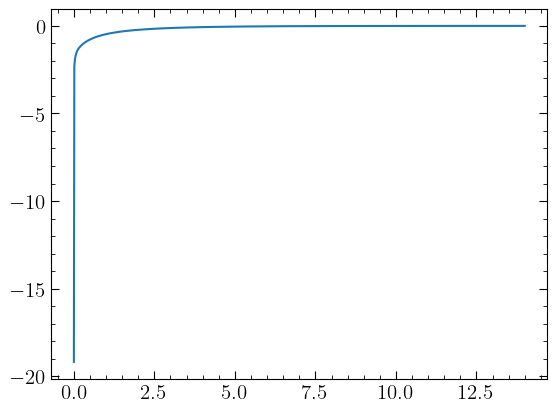

In [11]:
plt.plot(t_array[:], Mn_H)

In [12]:
mass_Fe = 55.85
mass_O = 16
mass_Mn = 54.94

A_Mn = 5.52 #Magg et al. 2022
A_Mn_error = 0.04


def get_solar_abundance_from_A(A, mass):
    log_Z_solar = A - 12 + np.log10(mass) + np.log10(0.71)
    return log_Z_solar

solar_Mn = 10**(get_solar_abundance_from_A(A_Mn, mass_Mn))
print("Solar_Mn is ", solar_Mn)

Solar_Mn is  1.2916564108120031e-05


In [13]:
alpha_cc_Mn=0.17
alpha_Ia_Mn=0.3
R_Ia_Mn=1.97

In [14]:
def K_Mn_Ia_solar(K_Fe_Ia, ratio):
    K_Mn_Ia_solar = K_Fe_Ia * ratio
    return K_Mn_Ia_solar

In [15]:
Z_Mn_solar = solar_Mn #look this up later, this is an incorrect value
def get_f_Ia(R_Ia_X):
    f_cc = (1 + R_Ia_X)**-1
    f_Ia = 1 - f_cc
    return f_Ia
f_Ia_Mn = get_f_Ia(R_Ia_X=R_Ia_Mn)
f_Ia_Fe = get_f_Ia(R_Ia_X=1)
Z_Fe_solar = gal1.SolarFe
Mn_Ia_solar_Fe_Ia_solar_ratio = Z_Mn_solar / Z_Fe_solar * f_Ia_Mn/f_Ia_Fe

In [16]:
K_Mn_Ia_solar_eg = K_Mn_Ia_solar(K_Fe_Ia=gal1.K_Fe_Ia_arr[0], ratio = Mn_Ia_solar_Fe_Ia_solar_ratio)

In [41]:
Z_Mn = 10**(Mn_H) * solar_Mn

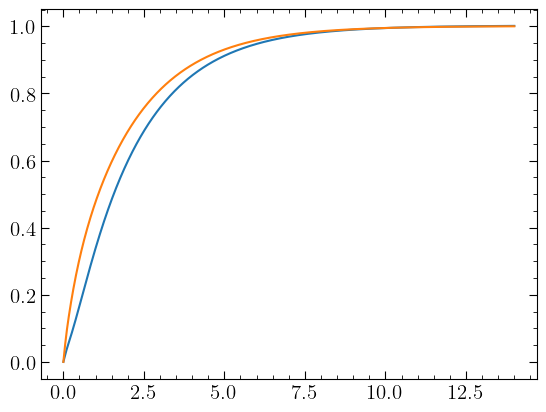

In [18]:
plt.plot(t_array[:], Z_Mn/solar_Mn)
plt.plot(t_array, Z_Fe_1/Z_Fe_solar)

In [19]:
function_of_metal_dep = Z_Mn/Z_Mn_solar

In [20]:
K_Mn_Ia = K_Mn_Ia_solar_eg * Z_Mn/Z_Mn_solar

In [27]:
K_Mn_Ia_solar

<function __main__.K_Mn_Ia_solar(K_Fe_Ia, ratio)>

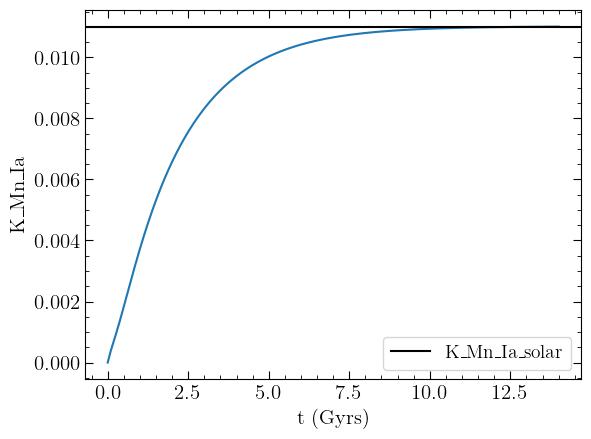

In [29]:
plt.plot(t_array, K_Mn_Ia)
plt.xlabel('t (Gyrs)')
plt.ylabel('K_Mn_Ia')
plt.axhline(K_Mn_Ia_solar_eg, label = 'K_Mn_Ia_solar', color = 'black')
plt.legend(fontsize=14)

Now we need to re-write the Ia process for Mn, and incorporate the metal dependant K in it. 

In [31]:
trial_Z_Mn_numerical = gal1.compute_z_Mn(K_Mn_Ia=K_Mn_Ia)
trial_Z_Mn_numerical_no_met_dep = gal1.compute_z_Mn(K_Mn_Ia=np.ones(len(t_array)) * K_Mn_Ia[-1])

Text(0.5, 0, 't (Gyrs)')

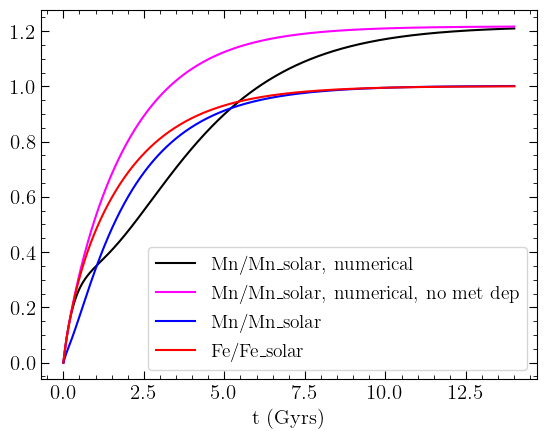

In [32]:
plt.plot(t_array, trial_Z_Mn_numerical/solar_Mn, color = 'black', label = 'Mn/Mn_solar, numerical')
plt.plot(t_array, trial_Z_Mn_numerical_no_met_dep/solar_Mn, color = 'magenta', label = 'Mn/Mn_solar, numerical, no met dep')
plt.plot(t_array, Z_Mn/solar_Mn, color = 'blue', label = 'Mn/Mn_solar')
plt.plot(t_array, Z_Fe_1/Z_Fe_solar, color = 'red', label = 'Fe/Fe_solar')

plt.legend(fontsize=14)
plt.xlabel('t (Gyrs)')

In [24]:
m_Fe_cc = gal1.m_Fe_cc_arr[0]
m_Mn_cc = Z_Mn_solar/Z_Fe_solar * m_Fe_cc
print(m_Mn_cc)

1.2916564108120031e-05


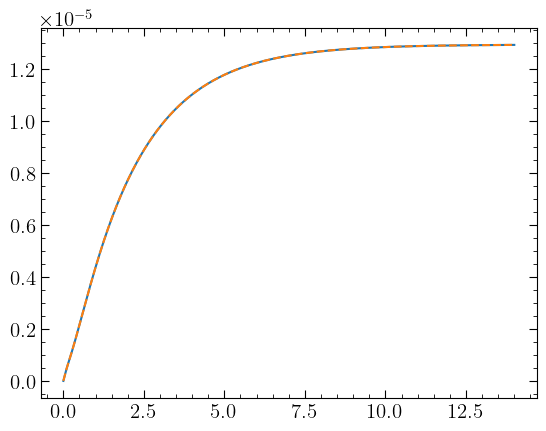

In [39]:
log_Z_Mn_check = Mn_H + A_Mn - 12 + np.log10(mass_Mn) + np.log10(0.71)
np.log10(0.71)
plt.plot(t_array, Z_Mn)
plt.plot(t_array, 10**log_Z_Mn_check, linestyle = '--')